# Multi Agent Systems: A5 - Continuous N Step Search
#### Deadline: 28-05-2026, 12:00 (noon!)

You may hand in the assignment up to a day late, in which case the assignment grade will be capped at 8. For any extensions please contact the TAs.

Hand in the notebook file on Brightspace, name your file as follows: $\textbf{A5_yourname.ipynb}$

Studentname: Ella Kemperman \
Studentnumber:  s1119890


$\textit{Don't forget to label your axis and give your graphs titles!}$

### AI Disclaimer

There is no need to use AI such as LLM based chatbots in the assignments (unless
explicitly said otherwise). While the use of AI is not forbidden, whenever AI is used,
you are expected to report what model was used, where was it used in the assignment,
how, and for what purpose. Use the cell below to summarise your AI use. 

**Also note it if you did not use AI! If so, we expect to see absolutely no signs of AI use in your assignment.**

---
#### FILL THIS IN
**Did you use AI for this assignment?** [yes/no]

**Model used:** e.g. *Claude AI*

**Used in:** e.g. *questions 1.1, 3.1*

**Why:** e.g. *To help me create plots and save time scouring documentation*

---

## Part 1 - Multi Agent Communication (2 points + 0.5 bonus)

**WE ASK YOU TO DO THE QUESTIONS IN PART 1 BY HAND AND UPLOAD A PHOTO OF YOUR ANSWER TOGETHER WITH THE ASSIGNMENT!**

A hiker is lost in a forest. You deploy a swarm of $N$ drones, each forming an
independent Gaussian belief over the hiker's location $\tau$. Assuming all agents
have a common mean (the expected target location) and variance (the uncertainty about that location)

$$P_i(\tau) \propto \exp\!\left(-\frac{(\tau - \mu)^2}{2\sigma^2}\right)$$

When the agents communicate, they multiply their beliefs to form a collective estimate:

$$P_{\text{global}}(\tau) \propto \prod_{i=1}^N P_i(\tau)$$

**Show that the collective belief is itself Gaussian, and find its variance.**

Use the following steps:

**1.** Substitute $P_i(\tau)$ into the product and express the product ($\Pi$) of exponentials as a sum ($\Sigma$) of exponents to express the global believe as a single exponential.

**2.** Match your result to the standard Gaussian form
$\exp\!\left(-\dfrac{(\tau-\mu)^2}{2\sigma_{\text{global}}^2}\right)$
to read off $\sigma_{\text{global}}^2$.

**3.** How does the global variance scale with $N$? What happens as $N \to \infty$?

**Bonus**\
**4.** Suppose each agent explores independently and collects data separately. As a result, agent i forms its own estimate with mean $\mu_i$ and $\sigma_i$

$$P_i(\tau) \propto \exp\!\left(-\frac{(\tau - \mu_i)^2}{2\sigma_i^2}\right)$$

When the agents communicate again, the global belief is again obtained by multiplying all individual beliefs. Again substitute $P_i(\tau)$. Expand, collect terms in $\tau$, and complete the square. \
    a) Show that the global belief
is still Gaussian, and derive $\mu_{\text{global}}$ and $\sigma_{\text{global}}^2$ in terms of $\mu_i, \sigma_i^2$. \
    b) Where was the global mean when all agents had identical estimates (question 1-3)? Where is the global mean localized when agents have varying estimates?

Substituting into the product:
$$P_{\text{global}}(\tau) \propto \prod_{i=1}^N\exp\left(-\frac{(\tau - \mu)^2}{2\sigma^2}\right)$$
Using exponent rewrite rules:
$$P_{\text{global}}(\tau) \propto \exp\left(\sum_{i=1}^N-\frac{(\tau - \mu)^2}{2\sigma^2}\right)$$
There is no dependence of $i$ in the sum:
$$P_{\text{global}}(\tau) \propto \exp\left(-N\frac{(\tau - \mu)^2}{2\sigma^2}\right)$$
Rewriting the $N$ into $\sigma$:
$$P_{\text{global}}(\tau) \propto \exp\left(-\frac{(\tau - \mu)^2}{2\left(\frac{\sigma}{\sqrt{N}}\right)^2}\right)$$
Yielding $\sigma_{\text{global}}^2 = \frac{\sigma^2}{N}$\
When taking $N\rightarrow \infty$:
$$\lim_{N\rightarrow\infty}\frac{\sigma^2}{N} = 0$$

In [1]:
# Just run this block to get a visual intuition on what is going on

# Swarm Sensing — Interactive Gaussian Belief (skeleton by Claude)
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output
from io import BytesIO

COLORS = ['#378ADD', '#1D9E75', '#D85A30', '#D4537E',
          '#BA7517', '#534AB7', '#3B6D11', '#7F77DD']
X             = np.linspace(-3, 3, 500)
PRODUCT_COLOR = '#1a1a2e'

# state
drones = []
_uid   = [0]

def _new_drone(mu, sigma):
    idx = _uid[0]
    d   = {'id': idx, 'mu': mu, 'var': sigma**2,  
           'active': True, 'color': COLORS[idx % len(COLORS)]}
    _uid[0] += 1
    return d

def reset_drones():
    drones.clear()
    _uid[0] = 0
    for mu, sigma in [(-0.3, 0.35), (0.2, 0.30), (-0.1, 0.40), (0.35, 0.30)]:
        drones.append(_new_drone(mu, sigma))
def gaussian(x, mu, var):
    return (1.0 / np.sqrt(2 * np.pi * var)) * np.exp(-0.5 * (x - mu)**2 / var) 

def compute_global(active):
    if not active:
        return None, None
    precision  = sum(1 / d['var'] for d in active)  
    var_glob   = 1 / precision                        
    mu_glob    = var_glob * sum(d['mu'] / d['var'] for d in active)
    return var_glob, mu_glob

#creating figure
plt.ioff()
fig, ax = plt.subplots(figsize=(9, 3.8))
plt.close(fig)

plot_out   = widgets.Image(format='png',
                           layout=widgets.Layout(width='100%'))
stats_html = widgets.HTML()

def redraw():
    active = [d for d in drones if d['active']]
    vg, mg = compute_global(active)
    ax.cla()

    for d in drones:
        y = gaussian(X, d['mu'], d['var'])        
        ax.plot(X, y,
                color     = d['color'],
                linewidth = 1.5  if d['active'] else 1.0,
                linestyle = '-'  if d['active'] else '--',
                alpha     = 0.75 if d['active'] else 0.18,
                label     = f"Drone {d['id']+1}  μ={d['mu']:.1f}  σ²={d['var']:.2f}")

    if active:
        prod = np.ones_like(X)
        for d in active:
            prod *= gaussian(X, d['mu'], d['var'])
        prod /= np.trapz(prod, X)
        ax.plot(X, prod, color=PRODUCT_COLOR, linewidth=3,
                label='Collective belief (product)', zorder=5)
        ax.fill_between(X, 0, prod, alpha=0.06, color=PRODUCT_COLOR)
        ax.axvline(x=mg, color=PRODUCT_COLOR, linewidth=1.2, linestyle='--',
                   alpha=0.6, label=f'μ_global = {mg:.2f}', zorder=4)

    ax.set_xlabel('Position target (τ)', fontsize=11)
    ax.set_ylabel('Belief  P(τ)', fontsize=11)
    ax.set_xlim(-3, 3)
    ax.set_ylim(bottom=0)                            
    #ax.spines[['top', 'right']].set_visible(False)
    ax.grid(True, alpha=0.12)
    ax.legend(loc='upper right', fontsize=9, framealpha=0.6,
              ncol=2 if len(drones) > 4 else 1)
    fig.tight_layout()
    buf = BytesIO()
    fig.savefig(buf, format='png', dpi=110, bbox_inches='tight')
    buf.seek(0)
    plot_out.value = buf.read()

# drone rows
drone_rows = widgets.VBox([])

def build_row(d):
    chk = widgets.Checkbox(
        value=d['active'], description='', indent=False,
        layout=widgets.Layout(width='30px', height='28px'))

    name = widgets.HTML(
        f'<span style="font-family:monospace; font-weight:600; color:{d["color"]}">'
        f'&#9632; Drone {d["id"]+1}</span>',
        layout=widgets.Layout(width='80px'))

    mu_sl = widgets.FloatSlider(
        value=d['mu'], min=-2, max=2, step=0.1,
        description='μ:',
        readout_format='.1f',
        continuous_update=False,
        style={'description_width': '24px'},
        layout=widgets.Layout(width='210px'))

    sig_sl = widgets.FloatSlider(
        value=d['var'], min=0.0025, max=0.25, step=0.005,  # σ∈[0.05,0.5] → σ²∈[0.0025,0.25]
        description='σ²:',
        readout_format='.2f',
        continuous_update=False,
        style={'description_width': '24px'},
        layout=widgets.Layout(width='210px'))

    del_btn = widgets.Button(
        description='x',
        layout=widgets.Layout(width='32px', height='28px'))
    del_btn._drone_id = d['id']

    def on_check(change, drone=d):
        drone['active'] = change['new']
        redraw()

    def on_mu(change, drone=d):
        drone['mu'] = change['new']
        redraw()

    def on_sigma(change, drone=d):
        drone['var'] = change['new']                
        redraw()

    def on_delete(btn):
        drones[:] = [x for x in drones if x['id'] != btn._drone_id]
        rebuild_rows()
        redraw()

    chk.observe(on_check,  names='value')
    mu_sl.observe(on_mu,   names='value')
    sig_sl.observe(on_sigma, names='value')
    del_btn.on_click(on_delete)

    return widgets.HBox(
        [chk, name, mu_sl, sig_sl, del_btn],
        layout=widgets.Layout(align_items='center', gap='6px'))

def rebuild_rows():
    drone_rows.children = [build_row(d) for d in drones]

add_btn   = widgets.Button(description='+ Add drone', button_style='primary',
                           layout=widgets.Layout(width='120px'))
same_btn  = widgets.Button(description='Same μ, σ²',
                           layout=widgets.Layout(width='110px'),
                           tooltip='4 identical drones (μ=0, σ²=0.09) — for Q1-3')
reset_btn = widgets.Button(description='Reset',
                           layout=widgets.Layout(width='80px'))

def on_add(_):
    mu    = round(float(np.random.uniform(-2, 2)),    1)
    sigma = round(float(np.random.uniform(0.05, 0.5)), 2)
    drones.append(_new_drone(mu, sigma))
    rebuild_rows()
    redraw()

def on_same(_):
    drones.clear(); _uid[0] = 0
    for _ in range(4):
        drones.append(_new_drone(0.0, 0.3))
    rebuild_rows(); redraw()

def on_reset(_):
    reset_drones()
    rebuild_rows(); redraw()

add_btn.on_click(on_add)
same_btn.on_click(on_same)
reset_btn.on_click(on_reset)

# display
header = widgets.HTML("""
<h3 style="margin:4px 0 2px; font-family:monospace">
    Swarm Sensing — Gaussian Belief
</h3>
<p style="font-size:12px; color:#666; margin:0 0 4px; font-family:monospace">
    thick dark line = collective belief &nbsp;|&nbsp;
    dashed = disabled drone &nbsp;&nbsp
</p>""")

hint = widgets.HTML("""
<p style="font-size:11px; color:#999; font-family:monospace; margin:4px 0 0">
    Q1-3: Same mean μ, variance σ²;
    Q4: Bonus: drag drones apart to watch μ_global shift
</p>""")

controls = widgets.HBox(
    [add_btn, same_btn, reset_btn],
    layout=widgets.Layout(gap='8px', margin='4px 0 0'))

reset_drones()
rebuild_rows()

ui = widgets.VBox(
    [header, plot_out, stats_html, drone_rows, controls, hint],
    layout=widgets.Layout(gap='5px'))

display(ui)
redraw()

AttributeError: module 'numpy' has no attribute 'trapz'

## Part 2 - Multiagent search n-step continuous optimization (centralized)


In [3]:
# Numpy numerical library -> import [library] as name
import numpy as np

# Plotting libraries -> matplotlib
import matplotlib.pyplot as plt 
from mpl_toolkits.mplot3d import Axes3D # 3D plots
from matplotlib import cm # Color maps
import matplotlib.colors as mcolors # colours for the different agents

# prior belief
from scipy.stats import multivariate_normal

# Matrix auxiliary functions
import numpy.matlib

# System libraries
import os
import sys

### Preparation

In this assignment, you will build on what you did in the previous assignment. Because of that, you will need to copy some of your code from assignment 4 to the cells below. More specifically, you need to copy the agent class and the two helper functions below. If you did not manage to get these working, don't hesitate to reach out, so that we can make sure you are still able to finish this assignment!

In [4]:
# example sensor values
Pdmax = 0.8 # Max range sensor
dmax = 4 # Max distance
sigma = 0.7 # Sensor spread (standard deviation)

In [100]:
class Agent:

    # Constructor
    def __init__(self, 
                 i, 
                 state=np.array([0.,0.]), 
                 map_size = np.array([40, 40]), 
                 bk = np.ones((40, 40))*(1./1600), 
                 color='r', 
                 delta = 0.5, 
                 Pdmax=Pdmax, 
                 dmax=dmax, 
                 sigma=sigma,
                 use_cam=False,
                 cam_dist: int = 10,
                 noise_intensity: float = 0.1,
                 view_angle: float = np.pi / 4,
                 A: float = 1,
                 lambda_: float = 0.9,
                 **kwargs
                ):
        
        self.id = i  # Create an instance variable
        self.map_size = map_size
        self.width, self.height = map_size[0], map_size[1]
        
        # Environment. Compute the grid into one vector as we did in the previous sections 
        x = y = np.arange(0, self.width) # This only works if both have the same size
        self.X, self.Y = np.meshgrid(x, y) # generate grid
        self.map = np.zeros((self.width, self.height))
        
        # belief
        self.bk = bk

        # Agent params
        self.x = state
        self.track = self.x.T # Stores all positions. Aux variable for visualization of the agent path
        self.height_plot = 0.1
        
        # add extra agents params 
        self.movement_directions = np.array([
            [0, 0],
            [0, delta],
            [delta, 0],
            [0, -delta],
            [-delta, 0],
            [delta, delta],
            [delta, -delta],
            [-delta, delta],
            [-delta, -delta]
        ])
        self.delta = delta
        self.color = color
        self.agent_label = i

        # Sensor params 
        self.Pdmax = Pdmax
        self.dmax = dmax
        self.sigma = sigma
        
        # Optional camera parameters
        self.use_cam = use_cam
        self.cam_dist = cam_dist
        self.noise_intensity = noise_intensity
        self.view_angle = view_angle
        self.A = A
        self.lambda_ = lambda_
    
    @property
    def belief(self):
        return self.bk
    
    @belief.setter
    def belief(self, new_belief: np.ndarray):
        self.bk = new_belief
    
    # get id
    def get_id(self):
        return self.id

    # compute discrete forward states 1 step ahead
    def forward(self):
        randomised = np.random.permutation(self.movement_directions)
        fs = randomised + self.x
        return fs[np.logical_and(np.logical_and(0 < fs[:, 0], fs[:, 0] < self.width), np.logical_and(0 < fs[:, 1], fs[:, 1] < self.height))]
    
    def range_sensor(self, pos, x, y):
        X = np.array([x, y])
        d = np.sum((pos - X)**2)**0.5
        return 1 - self.Pdmax * np.exp(-self.sigma * (d / self.dmax)**2)
    
    def camera(self, pos, x, y):
        dir_vec = np.array([np.cos(pos[-1]), np.sin(pos[-1])])  # Assume last element of the x_array contains angle theta
        target_vec = np.array([x, y]) - pos
        
        # Calculate angle between target position and current direction vector
        d = np.sum(target_vec**2)**0.5
        if d == 0:
            angle = pos[-1]
        else:
            angle = np.abs(np.arccos(np.dot(dir_vec, target_vec.T) / d))
        
        # Not in triangle, so probability of non-detection is 1
        # Note that this doesn't actually check Isosceles triangle, but an approximation using a circle centered at the agent, and checks if the target is within the circle, implying the bottom of the isosceles triangle is actually an arc in this implementation
        if angle > self.view_angle / 2 or d > self.cam_dist:
            return 1
        
        sigma_d = self.noise_intensity * d
        d_hat = np.random.normal(d, sigma_d)
        
        S = self.A / (d_hat**2)
        return 1 - np.exp(-self.lambda_ * S)
    
    # computes pnd of forward states
    def nodetect_observation(self, pos):
        pos = pos[:2]
        func = lambda x, y: self.camera(pos, x, y) if self.use_cam else self.range_sensor(pos, x, y)
        
        pnd = np.vectorize(func)(self.X, self.Y)
        return pnd / pnd.sum()
        
    # computes utility of states
    def utility(self, fs):
        # compute cost funtion J of all potential forward states (brute force method)
        p_d = self.nodetect_observation(fs)
        return np.sum(p_d * self.bk)

    def next_best_state(self):
        next_states = self.forward()
        utilities = np.vectorize(lambda next_state: self.utility(next_state), signature="(m) -> ()")(next_states)
        return next_states[np.argmin(utilities)]
      
    # simulate agent next state
    def next(self, state):
        self.x = state
        self.track = np.vstack((self.track, self.x))

    # update belief with observation at state self.x
    def update_belief(self):
        update = self.nodetect_observation(self.x)
        belief = self.bk * update
        self.bk = belief / np.sum(belief)
        
    def get_pnd(self):
        return self.nodetect_observation(self.x)
      
    def plot(self, ax, plot_surface=False):
        if plot_surface:
            ax.plot_surface(self.X, self.Y, self.bk, rstride=3, cstride=3, linewidth=1, antialiased=True, cmap=cm.viridis)
        
        # plot contour of the P(\tau) -> self.bk
        cset = ax.contourf(self.X, self.Y, self.bk, zdir='z', offset=-self.height_plot / 2, cmap=cm.viridis, alpha=0.5)

        # plot agent trajectory, self.track
        ax.plot(self.track[:, 0], self.track[:, 1], np.ones(self.track.shape[0]) * self.height_plot, '-', linewidth=2, color=self.color, label=self.agent_label)
        ax.plot([self.track[-1, 0], self.track[-1, 0]], [self.track[-1, 1], self.track[-1, 1]], [self.height_plot, 0], 'ko-', linewidth=2)

        ax.set_xlabel('x')
        ax.set_ylabel('y')
        ax.set_zlabel('P')

        # Adjust the limits, ticks and view angle
        ax.set_zlim(-self.height_plot / 2.2, self.height_plot * 1.2)
        ax.view_init(27, -21)
        
        plt.draw()

In [54]:
def bivariate_gaussian(w, h, mu, sigma):
    """
    Generate the pdf of a bivariate gaussian distribution in a specific world

    Parameters
    ----------
    w : int
        the width of the world
    h : int
        the height of the world
    mu : array of integers
        the mean of the gaussian 
    sigma : array of integers
        the covariance of the gaussian

    Returns
    -------
    array of integers
        the bivariate gaussian

    """
    def inner(x, y):
        X = np.array([x, y])
        return (2 * np.pi)**(-sigma.shape[0] / 2) * np.linalg.det(sigma)**(-0.5) * np.exp(-0.5 * (X - mu).T @ np.linalg.inv(sigma) @ (X - mu))

    x = np.arange(0, w)
    y = np.arange(0, h) # This only works if both have the same size
    X, Y = np.meshgrid(x, y) # generate grid
    return np.vectorize(inner)(X, Y)

def random_agent_start_pos(w, h):
    """
    Randomly selects the starting position of an agent in a specific world

    Parameters
    ----------
    w : int
        width of the world
    h : int
        height of the world

    Returns
    -------
    array of 2 integers
        a position in the world

    """
    return np.random.randint(np.array([w, h]))

In [55]:
# Custom helper classes
class ColorGenerator:
    """Class that infinitely spits out colours for matplotlib plots"""    
    def __init__(self, pre_colors = ("r", "g", "b", "y", "orange", "pink")):
        self._i = 0
        self._pre_colors = pre_colors
    
    def __iter__(self):
        for color in self._pre_colors:
            yield color
        while True:
            yield np.random.random(), np.random.random(), np.random.random()

class MultiAgentSystem:
    """Class for handling systems of multiple agents"""
    def __init__(self, agent_count: int, width: int, height: int, start_belief: np.ndarray, shared_belief: bool = False, agent_constructor = Agent, iterable_kwargs = None, **agent_kwargs):
        if iterable_kwargs is None:
            iterable_kwargs = [{} for _ in range(agent_count)]
        color_generator = ColorGenerator().__iter__()
        self._agents = [agent_constructor(i, state=random_agent_start_pos(width, height), map_size = np.array([width, height]), bk=start_belief, color=next(color_generator), **iterable_kwargs[i], **agent_kwargs) for i in range(agent_count)]
        self._use_shared_belief = shared_belief
        self._shared_belief = start_belief
        
    def update(self):
        for agent in self._agents:
            next_state = agent.next_best_state()
            agent.next(next_state)
            if not self._use_shared_belief:
                agent.update_belief()
                
        if self._use_shared_belief:
            self._update_shared_beliefs()
            
    def _update_shared_beliefs(self):
        for agent in self._agents:
            self._shared_belief *= agent.get_pnd()
        # Normalise belief
        self._shared_belief = self._shared_belief / np.sum(self._shared_belief)
        for agent in self._agents:
            agent.belief = self._shared_belief
        
    def plot_agents(self, ax):
        for agent in self._agents:
            agent.plot(ax)

#### Agent dynamics

The previous assignment had you implement multi-agent greedy search in a discrete world. Here, we will be going one step further, and implement agents that search in a continuous manner, while also optimizing over multiple steps in the future. This section describes how to incorporate continuous optimization. Agents will select the n-actions ahead collaborativelly that maximize the probability of finding the survivors. The agents will perform continuous piece-wise actions:

<img src="img/actions-continuous.png" width="400" />

From state $s^k$ at time step $k$ to time step $k+1$ the agent perform the turn action $u^k$ (constant) that makes the agent change its heading. Then, when arriving at state $s^{k+1}$ the agent makes an observation $z^k$.

We define the agent state the $s = \{x,y,\phi\}$, where $\phi$ is the turning angle. The state dynamics $\dot{s}$ are defined by its differential equations. Below we provide the function to compute the next state given the action (turn rate), make sure that you understand this code. This class inherits from your agent class defined above, and it overwrites the "next" function

In [101]:
class AgentContinuous(Agent):

    # Constructor
    def __init__(self, i, state=np.array([0.,0.]), map_size = np.array([40, 40]), bk = np.ones(1600)*(1./1600), color = 'r', **kwargs):
        super().__init__(i, state, map_size, bk, color, **kwargs) # pass arguments to superclass
        self.V = 2  # Velocity of the agent
        self.dt = 1  # Interval for euler integration (continuous case)
        self.max_turn_change = 0.2  # Max angle turn (action bounds)
        
        self.x = np.array([state[0], state[1], 0.2]) # state (x, y, turning angle)
        self.track = self.x.T # Stores all positions
    
    def sim_next(self, vk):
        # singular case u = 0 -> the integral changes
        x = np.array([0, 0, 0])
        if vk == 0:
            x_0 = self.x[0] + self.dt * self.V * np.cos(self.x[2])
            x_1 = self.x[1] + self.dt * self.V * np.sin(self.x[2])
            theta = self.x[2]
        else:
            desp = self.V / vk
            if np.isinf(desp) or np.isnan(desp):
                print('forwardstates:V/u -> error');
            x_0 = self.x[0] + desp * (np.sin(self.x[2] + vk * self.dt) - np.sin(self.x[2]))
            x_1 = self.x[1] + desp * (-np.cos(self.x[2] + vk * self.dt) + np.cos(self.x[2]))
            theta = self.x[2] + vk * self.dt
        x_0 = np.clip(x_0, a_min=0, a_max=self.width)
        x_1 = np.clip(x_1, a_min=0, a_max=self.height)
        return np.array([x_0, x_1, theta])
    
    # set next state
    def next(self, vk):
        self.x = self.sim_next(vk)
        self.track = np.vstack((self.track, self.x))

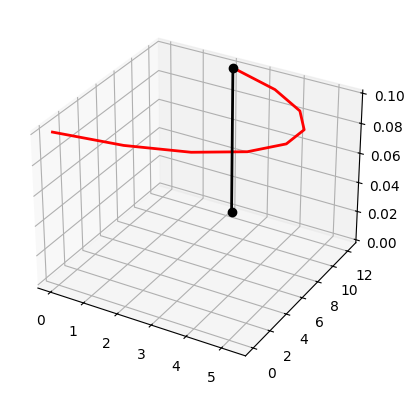

In [96]:
# plot in notebook
%matplotlib inline 

# Create an Agent and plot it
a = AgentContinuous(i=0)

for i in range(8):
    a.next(0.3)

# plot agent trajectory, self.track   
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot(a.track[:, 0], a.track[:, 1], np.ones(a.track.shape[0]) * 0.1, 'r-', linewidth=2);
ax.plot([a.track[-1, 0], a.track[-1, 0]], [a.track[-1, 1], a.track[-1, 1]], [0.1, 0], 'ko-', linewidth=2);
plt.show()

### Multiagent n-step ahead utility function (3 points)
We need a function that evaluates how good the actions of the team are. We have $M$ agents and we want to compute the $N$ step ahead actions that optimize the following function:

$$ U(x) = \int_{\tau} \prod_{j=0}^N \prod_{i=0}^M p(\overline{D}| x_{i}^{k+j},\tau) b_\tau^{k-1} d\tau$$

Remember that the state $x^{k+1}$ is directily obtained by a function of the previous state $x^{k}$ and the action $u^k$.
Program the utility function in your script using the template below. You will need to define an additional function (within or outside the AgentContinuous class) that computes the next state given a specific state and action.

In [44]:
def multi_utility(uk: np.ndarray, agents: list, N: int, bk: np.ndarray):
    """
    Calculate the utility of a worldstate given actions

    Parameters
    ----------
    uk : array of floats
        the actions that the agents will take
    agents : array of Agents
        the agents in the current world
    N : int
        how many steps to look in the future
    bk : 2D array of floats
        the common belief

    Returns
    -------
    int
        the utility of a worldstate
        
    """
    pnd = 1
    uk_ = uk.reshape((len(agents), N))
    for i, agent in enumerate(agents):
        for j in range(N):
            new_pos = agent.sim_next(uk_[i, j])
            pnd *= agent.nodetect_observation(new_pos)
    return np.sum(bk * pnd)

#### Optimizer
In order to compute the best actions we will use a general optimizer from scipy python library. The optimizer returns the best actions found.

In [35]:
import scipy.optimize as opt

class Optimizer:

    def __init__(self):
        self.method = 'trust-constr' # Optimization method
        self.jac = "2-point" # Automatic Jacobian finite differenciation
        self.hess =  opt.SR1() # opt.BFGS()
        self.ul = np.pi / 4  # Max turn constraint for our problem (action limits)

    def optimize(self, fun, x0, agents, N, bk):
        # write your optimization call using scipy.optimize.minimize
        n = x0.shape[0]
        # Define the bounds of the variables in our case the limits of the actions variables
        bounds = opt.Bounds(np.ones(n) * (-self.ul), np.ones(n) * self.ul) 
        # minimize the cost function. Note that I added the as arguments the extra variables needed for the function.
        res = opt.minimize(fun, x0, args=(agents, N, bk), method=self.method, jac=self.jac, hess=self.hess, bounds=bounds)
        #  options={'verbose': 1})
        return res

### N-step continuous code (2 points)
Using everything defined before, please implement the search loop. Make it use 3 agents with continuous actions and that select the best actions using the optimizer. They use a common belief. Experiment with different N-steps. A plot of the agents working:

<img src="img/solution-continuous.png" width="400" />

In [57]:
class ContinuousMultiAgentSystem(MultiAgentSystem):
    def __init__(self, optimizer: Optimizer, N: int, **kwargs):
        super().__init__(shared_belief=True, **kwargs)
        self._optim = optimizer
        self._N = N
    
    def update(self):
        # initial actions as a list of zeroes
        x0 = np.zeros((len(self._agents), N)).flatten()
        # best actions determined by the optimizer (use common belief)
        uk = self._optim.optimize(multi_utility, x0, self._agents, self._N, self._shared_belief).x
        # calculate and update new common belief, set to all agents
        self._update_shared_beliefs()
        for i, agent in enumerate(self._agents):
            agent.next(uk[i])
    

Using matplotlib backend: inline
-------------------------------------------------

> M-Agents search 2D (continuous n-step ahead with centralized optimization)

0/10 steps


KeyboardInterrupt: 

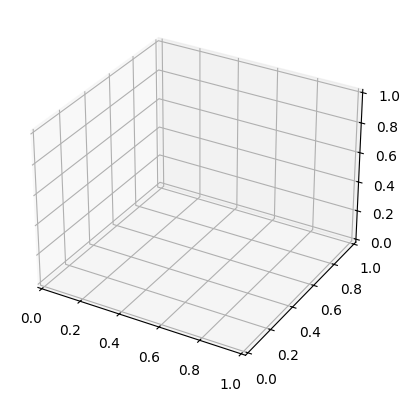

In [69]:
# allow animations to work within notebook
%matplotlib

print('-------------------------------------------------\n');
print('> M-Agents search 2D (continuous n-step ahead with centralized optimization)\n')
        
Magents = 3

# Create initial belief and environment
w = h = 40
mu = np.array([w/2, h/2])
Sigma = np.array([[40,0], [0,60]])
bk = bivariate_gaussian(w, h, mu, Sigma)

# Define optimizer
optim = Optimizer()

# Global plot for animations
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
plt.ion()

# Start algorithm
ite = 0  # iteration count
nite = 10  # number of iterations
found = 0  # target found (this parameter will not be used in the assignments as we assume that it is never found)
N = 3 # steps to look in the future

# Create agents
agents = ContinuousMultiAgentSystem(optim, N, agent_count=Magents, width=w, height=h, start_belief=bk, agent_constructor=AgentContinuous)

## start search
while not found and ite < nite:
    print(f"\r{ite}/{nite} steps")
    agents.update()

    # iteration count
    ite += 1
    
agents.plot_agents(ax)
ax.legend()
ax.set_title("Stochastic Multi-agent search at different noise levels")
plt.draw() # animation

## Part 3 - Multiagent search with a noisy camera sensor (3 points)

Now instead of the sensor used until now, we are going to use a camera sensor. For that purpose we first need to model the camera.

<img src="img/camera-sensor-model.png" width="400" />


The requirements are as follows:

1. Only targets in the field of view of the camera can be detected. Thus, the region of the FOV should be computed. The FOV depends on the agent location and orientation. We assume that the agent has a camera facing the direction of the movement.
_Note that the FOV is an isosceles triangle defined by the view angle (e.g. 90 degrees) and the maximum distance (e.g. 10)_
2. The probability of detecting the target with the vision system grows exponentially with the size of the object in the captured image, parametrized by the effectiveness $\lambda$ of the vision based detection algorithm $e^{(-\lambda S)}$.
3. The size of the object $S$ in the camera depends on the area of the object $A$ and varies with the inverse of the square of the distance $d$: $S = \dfrac{A}{d^2}$.
4. Finally, our camera is not perfect, and will be noisy. The camera becomes less reliable when the object is further away. We can represent this as follows:
    * $\sigma_d(d) = \alpha * d$, where $\alpha$ is a prefactor that determines the noise intensity.
    * Then, $\hat{d} = d + \mathcal{N}(0,\sigma_d^2)$
5. Use $\hat{d}$ when determining $S$. Do not forget to normalize at the end.

Once you implemented the camera sensor you can test it in the discrete and the continuous optimization approach with three agents.

You are implementing a simplified version of the camera in Section 4.3 of the following reference, where the orientation of the target also affects the detection probability: https://www.mdpi.com/1424-8220/14/8/14131 

Update your agent class above (or copy it below), and implement a function that calculates the pnd over the grid as if the agent uses a camera. Also give the class definition an extra parameter that decides what sensor to use. When the camera is chosen as sensor, it should use that to calculate the probability of non-detection. Create a new searching loop below to test it with the continuous N-step ahead algorithm, and give different agents different noise intensities (no noise, low noise, high noise). At what $\alpha$ does the search appear to become stochastic again?

Using matplotlib backend: inline
-------------------------------------------------

> M-Agents search 2D (continuous n-step ahead with centralized optimization and camera sensor)

0/10 steps
[13.96013316  2.39733866  0.2       ]
1/10 steps
[15.92026631  2.79467732  0.2       ]
2/10 steps
[17.88039947  3.19201598  0.2       ]
3/10 steps
[19.84053262  3.58935465  0.2       ]
4/10 steps
[21.80066578  3.98669331  0.2       ]
5/10 steps
[23.76079893  4.38403197  0.2       ]
6/10 steps
[25.72093209  4.78137063  0.2       ]
7/10 steps
[27.68106525  5.17870929  0.2       ]
8/10 steps
[29.6411984   5.57604795  0.2       ]
9/10 steps
[31.60133156  5.97338662  0.2       ]


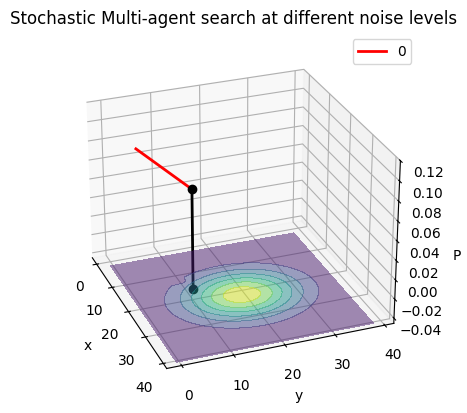

In [102]:
# allow animations to work within notebook
%matplotlib

print('-------------------------------------------------\n')
print('> M-Agents search 2D (continuous n-step ahead with centralized optimization and camera sensor)\n')
Magents = 1

# Create initial belief and environment
w = h = 40
mu = np.array([w/2, h/2])
Sigma = np.array([[40,0], [0,60]])
bk = bivariate_gaussian(w, h, mu, Sigma)

# Define optimizer
optim = Optimizer()

# Global plot for animations
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
plt.ion()

# Start algorithm
ite = 0  # iteration count
nite = 10  # number of iterations
found = 0  # target found (this parameter will not be used in the assignments as we assume that it is never found)
N = 3 # steps to look in the future

# Create agents
noise_intensities = [0, 0, 0]
noise_intensities_kwargs = [{"noise_intensity": noise_intensity} for noise_intensity in noise_intensities]

agents = ContinuousMultiAgentSystem(optim, N, agent_count=Magents, width=w, height=h, start_belief=bk, agent_constructor=AgentContinuous, iterable_kwargs=noise_intensities_kwargs, use_cam=True)

## start search
while not found and ite < nite:
    print(f"\r{ite}/{nite} steps")
    agents.update()
    print(agents._agents[0].x)
    # iteration count
    ite += 1

agents.plot_agents(ax)
ax.legend()
ax.set_title("Stochastic Multi-agent search at different noise levels")
plt.draw() # animation

$\textbf{YOUR TEXT ANSWER HERE}$